In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect("../data/processed/cosmere.db")

def sql_query(query):
    
    result = pd.read_sql_query(query, conn)
   
    return result

In [22]:
df = pd.read_sql_query("SELECT * from books", conn)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             19 non-null     str    
 1   series            19 non-null     str    
 2   series_order      19 non-null     int64  
 3   hardcover_id      19 non-null     int64  
 4   release_year      19 non-null     int64  
 5   pages             19 non-null     int64  
 6   rating            19 non-null     float64
 7   ratings_count     19 non-null     int64  
 8   reviews_count     19 non-null     int64  
 9   users_read_count  19 non-null     int64  
 10  has_audiobook     19 non-null     int64  
 11  has_ebook         19 non-null     int64  
 12  genres            19 non-null     str    
 13  moods             19 non-null     str    
 14  content_warnings  19 non-null     str    
 15  description       19 non-null     str    
dtypes: float64(1), int64(9), str(6)
memory usage: 2.5 KB


In [23]:
df['has_audiobook'] = df['has_audiobook'].astype(bool)
df['has_ebook'] = df['has_ebook'].astype(bool)

In [24]:
df['genres'] = df['genres'].str.split('|')
df['moods'] = df['moods'].str.split('|')

In [25]:
df[['title', 'genres', 'moods', 'has_audiobook']].head()

,title,genres,moods,has_audiobook
0,Mistborn: The Final Empire,"[Fantasy, Adventure, Young Adult, Fiction, Hig...","[Adventurous, mysterious, dark, tense, emotion...",True
1,The Well of Ascension,"[Fantasy, Fiction, Adventure, Dystopian, Epic ...","[Adventurous, mysterious, tense, dark, emotion...",True
2,The Hero of Ages,"[Fantasy, Fiction, Adventure, Dystopian, Ficti...","[Adventurous, emotional, tense, dark, mysterio...",True
3,The Alloy of Law,"[Fantasy, Science Fiction, Fiction, Retail, Ad...","[Adventurous, mysterious, funny, tense, lighth...",True
4,Shadows of Self,"[Fantasy, Science Fiction, Fiction, Imaginary ...","[Adventurous, mysterious, funny, emotional, te...",True


In [26]:
df["moods"] = df["moods"].apply(lambda moods: [mood.strip('"[]').lower() for mood in moods if not mood.isdigit()])

In [27]:
mood_counts = df["moods"].explode().value_counts()

In [28]:
mood_counts

moods
adventurous     20
tense           20
emotional       20
mysterious      18
hopeful         18
reflective      17
dark            16
inspiring       16
challenging     16
funny           13
sad             12
lighthearted    11
informative      6
relaxing         4
medium-paced     3
fast-paced       2
exciting         1
intense          1
romantic         1
surprising       1
Name: count, dtype: int64

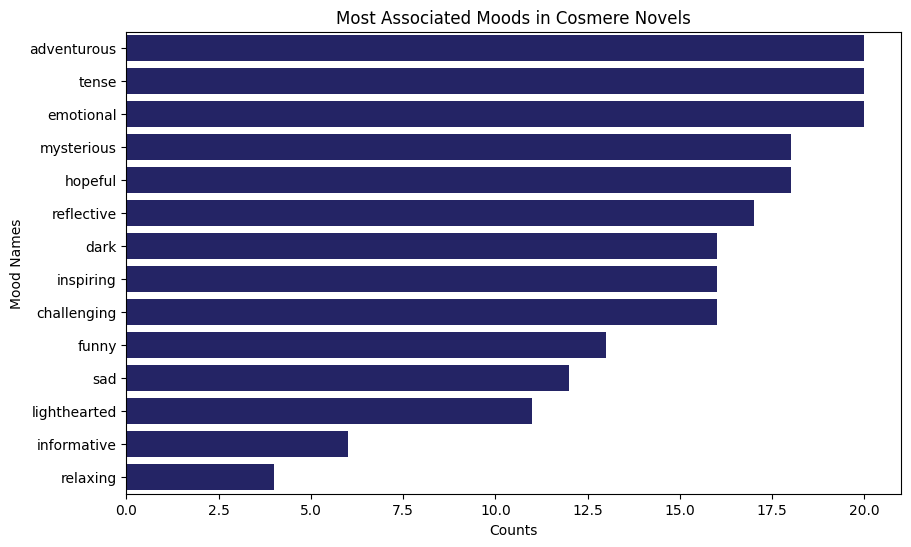

In [ ]:
mood_counts_filtered = mood_counts[mood_counts > 3]

plt.figure(figsize=(10, 6))
sns.barplot(x=mood_counts_filtered.values, y=mood_counts_filtered.index, color="midnightblue")
plt.xlabel("Counts")
plt.ylabel("Mood Names")
plt.title("Moods most Associated with Cosmere Novels")
plt.show()